In [1]:
import os, random
import numpy as np
import torch

# Make experiments reproducible
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)  # fix seed

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(" Environment setup complete. Using device:", device)

 Environment setup complete. Using device: cuda


### Dataset Exploration & Visualization

Classes found: ['hail', 'rainbow', 'frost', 'rime', 'fogsmog', 'snow', 'rain', 'glaze', 'lightning', 'sandstorm', 'dew']

Image count per class:
hail: 591
rainbow: 232
frost: 475
rime: 1160
fogsmog: 851
snow: 621
rain: 526
glaze: 639
lightning: 377
sandstorm: 692
dew: 698


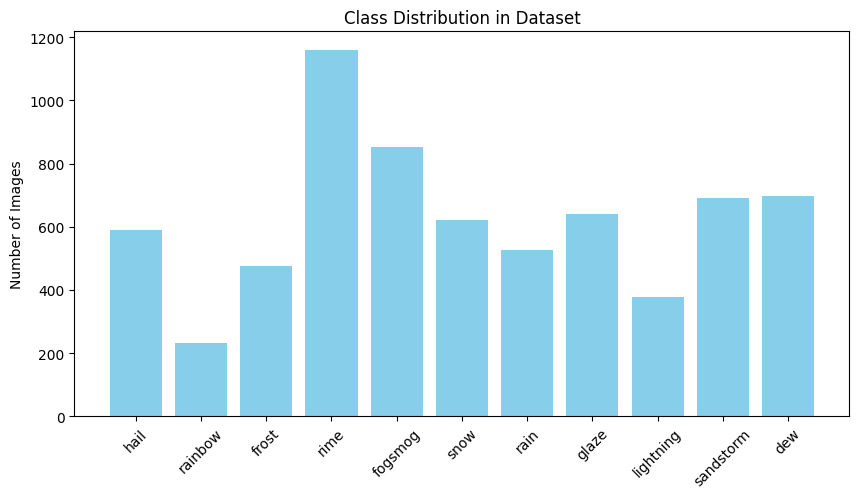

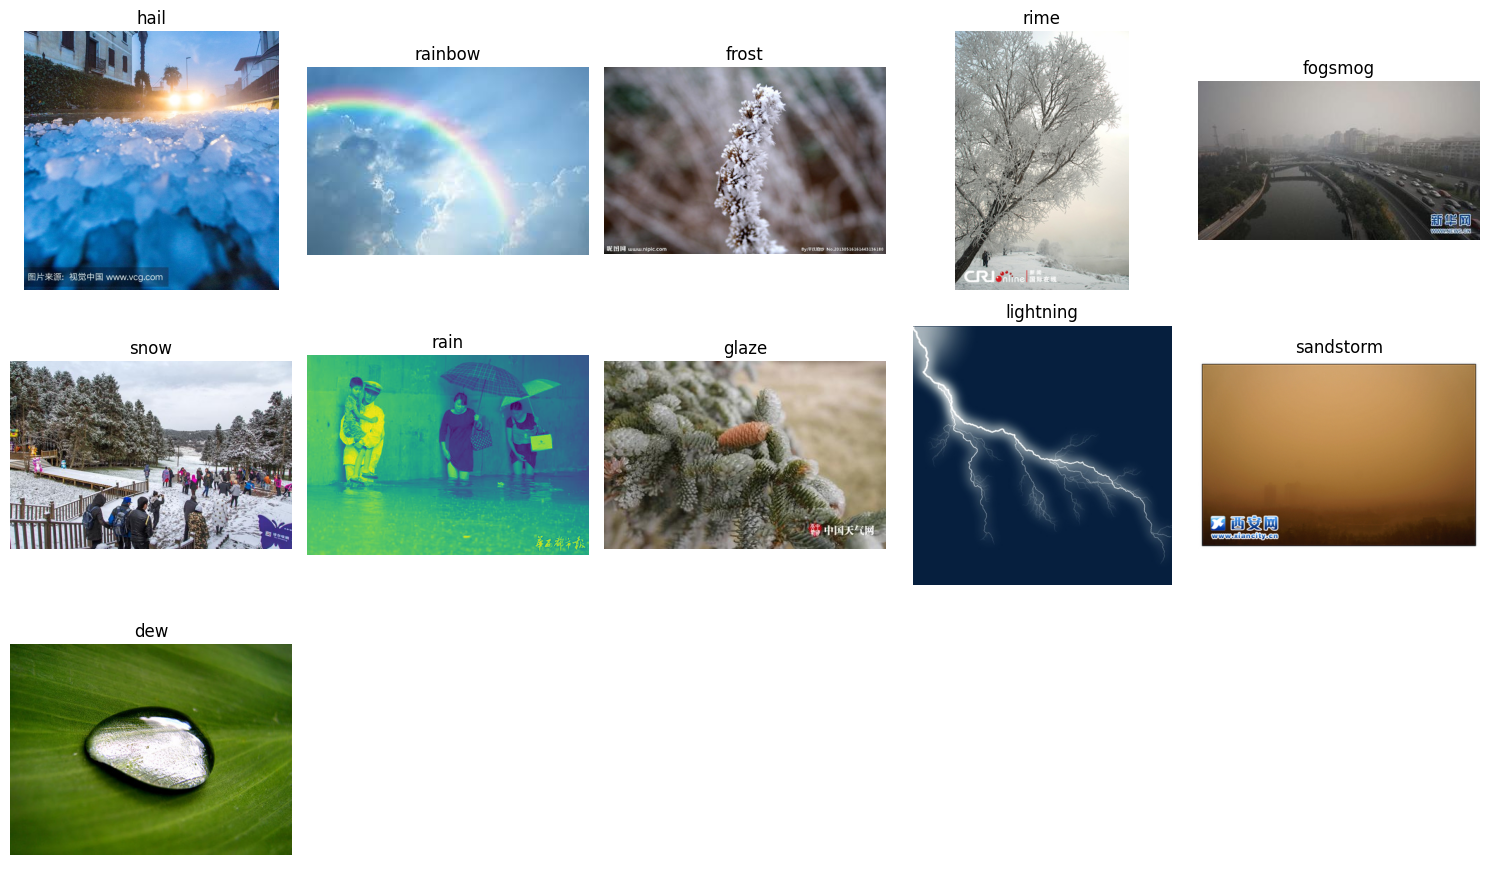

In [2]:
import matplotlib.pyplot as plt
from PIL import Image

# Correct dataset path
dataset_path = "/kaggle/input/weather-dataset/dataset"

# Get classes (subfolders)
classes = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
print("Classes found:", classes)

# Count images per class
class_counts = {}
for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    class_counts[cls] = len(os.listdir(cls_path))

print("\nImage count per class:")
for k,v in class_counts.items():
    print(f"{k}: {v}")

# Plot class distribution
plt.figure(figsize=(10,5))
plt.bar(class_counts.keys(), class_counts.values(), color="skyblue")
plt.xticks(rotation=45)
plt.title("Class Distribution in Dataset")
plt.ylabel("Number of Images")
plt.show()

# Show sample images dynamically
n_classes = len(classes)
cols = min(5, n_classes)  # max 5 per row
rows = (n_classes + cols - 1) // cols

fig, axs = plt.subplots(rows, cols, figsize=(15, 3*rows))

# Make axs always iterable
if rows * cols == 1:
    axs = [axs]
else:
    axs = axs.flatten()

for i, cls in enumerate(classes):
    cls_path = os.path.join(dataset_path, cls)
    sample_img = os.listdir(cls_path)[0]  # pick first image
    img = Image.open(os.path.join(cls_path, sample_img))
    axs[i].imshow(img)
    axs[i].set_title(cls)
    axs[i].axis("off")

# Hide unused plots
for j in range(i+1, len(axs)):
    axs[j].axis("off")

plt.tight_layout()
plt.show()

### Compute Class Weights

In [3]:
import torch
import numpy as np

# Use class_counts we already computed
total_samples = sum(class_counts.values())
num_classes = len(class_counts)

# Compute class weights (higher weight for smaller classes)
class_weights = {
    cls: total_samples / (num_classes * count)
    for cls, count in class_counts.items()
}

# Convert to tensor (order must match dataset.classes)
weights_list = [class_weights[cls] for cls in classes]
class_weights_tensor = torch.tensor(weights_list, dtype=torch.float).to(device)

print(" Class Weights (for loss):")
for cls, w in zip(classes, weights_list):
    print(f"{cls}: {w:.4f}")

 Class Weights (for loss):
hail: 1.0555
rainbow: 2.6889
frost: 1.3133
rime: 0.5378
fogsmog: 0.7330
snow: 1.0045
rain: 1.1860
glaze: 0.9762
lightning: 1.6547
sandstorm: 0.9015
dew: 0.8937


### Dataset Splitting (70/15/15)

In [4]:
import shutil
from sklearn.model_selection import train_test_split

# Source (original dataset) and target (split dataset)
source_path = "/kaggle/input/weather-dataset/dataset"
split_path = "/kaggle/working/weather_split"

# Ensure reproducibility
set_seed(42)

# Only split once (to avoid duplication on reruns)
if not os.path.exists(os.path.join(split_path, "train")):
    for split in ["train", "val", "test"]:
        os.makedirs(os.path.join(split_path, split), exist_ok=True)
    
    for cls in classes:
        cls_path = os.path.join(source_path, cls)
        images = [os.path.join(cls_path, f) for f in os.listdir(cls_path)]
    

        train_imgs, temp_imgs = train_test_split(images, test_size=0.30, random_state=42)
        val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.50, random_state=42)
        
        # Create class folders in target
        for split in ["train", "val", "test"]:
            os.makedirs(os.path.join(split_path, split, cls), exist_ok=True)
        
       
        for img in train_imgs:
            shutil.copy(img, os.path.join(split_path, "train", cls))
        for img in val_imgs:
            shutil.copy(img, os.path.join(split_path, "val", cls))
        for img in test_imgs:
            shutil.copy(img, os.path.join(split_path, "test", cls))

print(" Dataset successfully split into train/val/test at:", split_path)

 Dataset successfully split into train/val/test at: /kaggle/working/weather_split


### DataLoader + Transforms Setup

In [5]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ImageNet mean & std (since we're using pretrained transformers)
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

# Train transforms (with augmentation)
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.3, 0.3, 0.2, 0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

# Validation/Test transforms (no heavy augmentation)
val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

# Dataset paths
train_dir = os.path.join(split_path, "train")
val_dir   = os.path.join(split_path, "val")
test_dir  = os.path.join(split_path, "test")

# Datasets
train_ds = datasets.ImageFolder(train_dir, transform=train_transform)
val_ds   = datasets.ImageFolder(val_dir, transform=val_transform)
test_ds  = datasets.ImageFolder(test_dir, transform=val_transform)

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

print(" DataLoaders ready!")
print(f"Train: {len(train_ds)} images")
print(f"Val:   {len(val_ds)} images")
print(f"Test:  {len(test_ds)} images")
print("Classes:", train_ds.classes)

 DataLoaders ready!
Train: 4798 images
Val:   1031 images
Test:  1033 images
Classes: ['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']


### Training Setup

In [6]:
import torch.nn as nn
import timm

class ConvStemSwin(nn.Module):
    def __init__(self, model_name="swin_small_patch4_window7_224", pretrained=True, num_classes=11):
        super().__init__()
        
        # CNN stem (captures local weather textures like frost, snowflakes, rain streaks)
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )
        
        # Swin Transformer backbone (no classifier head yet)
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0, in_chans=64)
        
        # Classification head
        self.fc = nn.Linear(self.backbone.num_features, num_classes)
    
    def forward(self, x):
        x = self.stem(x)
        x = self.backbone(x)
        x = self.fc(x)
        return x

# Create model
num_classes = len(train_ds.classes)
model = ConvStemSwin(num_classes=num_classes).to(device)

print(" Model created: ConvStem + Swin Transformer")
print(model)

model.safetensors:   0%|          | 0.00/200M [00:00<?, ?B/s]

 Model created: ConvStem + Swin Transformer
ConvStemSwin(
  (stem): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
  )
  (backbone): SwinTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(64, 96, kernel_size=(4, 4), stride=(4, 4))
      (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    )
    (layers): Sequential(
      (0): SwinTransformerStage(
        (downsample): Identity()
        (blocks): Sequential(
          (0): SwinTransformerBlock(
            (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
            (attn): WindowAttention(
              (qkv): Linear(in_features=96, out_features=288, bias=True)
              (

In [7]:
class ConvStemSwin(nn.Module):
    def __init__(self, model_name="swin_small_patch4_window7_224", pretrained=True, num_classes=11):
        super().__init__()
        
        # Light CNN stem (but output channels = 3 so Swin still sees RGB-like input)
        self.stem = nn.Sequential(
            nn.Conv2d(3, 3, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(3),
            nn.ReLU()
        )
        
        # Swin Transformer backbone (expects 3-channel 224x224)
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=num_classes, in_chans=3)

    def forward(self, x):
        x = self.stem(x)          # keep shape [B, 3, 224, 224]
        x = self.backbone(x)      # Swin handles patch embedding + transformer
        return x

# Create model
num_classes = len(train_ds.classes)
model = ConvStemSwin(num_classes=num_classes).to(device)

print(" Fixed model created: ConvStem + Swin (input 224x224, 3ch)")

 Fixed model created: ConvStem + Swin (input 224x224, 3ch)


In [8]:
import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import copy
import time

# Loss function with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Optimizer & scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

print(" Training setup complete (loss, optimizer, scheduler ready)")

 Training setup complete (loss, optimizer, scheduler ready)


In [9]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=20):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-"*30)

        # Training phase
        model.train()
        train_loss, train_preds, train_labels = 0.0, [], []

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(labels.cpu().numpy())

        train_loss /= len(train_loader.dataset)
        train_acc = accuracy_score(train_labels, train_preds)

        # Validation phase
        model.eval()
        val_loss, val_preds, val_labels = 0.0, [], []

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * imgs.size(0)
                preds = outputs.argmax(dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_loss /= len(val_loader.dataset)
        val_acc = accuracy_score(val_labels, val_preds)
        val_f1 = f1_score(val_labels, val_preds, average="macro")

        scheduler.step()

        # Save history
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val Loss:   {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")

        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(best_model_wts, "best_model.pth")
            print(" Best model updated and saved!")

    print("\nTraining complete. Best Val Acc: {:.4f}".format(best_acc))
    model.load_state_dict(best_model_wts)
    return model, history

# Run training
model, history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=20)


Epoch 1/20
------------------------------
Train Loss: 0.6608, Train Acc: 0.7380
Val Loss:   0.4170, Val Acc: 0.8642, Val F1: 0.8722
 Best model updated and saved!

Epoch 2/20
------------------------------
Train Loss: 0.2939, Train Acc: 0.8756
Val Loss:   0.3390, Val Acc: 0.8952, Val F1: 0.8992
 Best model updated and saved!

Epoch 3/20
------------------------------
Train Loss: 0.1859, Train Acc: 0.9229
Val Loss:   0.3308, Val Acc: 0.9030, Val F1: 0.9061
 Best model updated and saved!

Epoch 4/20
------------------------------
Train Loss: 0.1293, Train Acc: 0.9460
Val Loss:   0.3135, Val Acc: 0.9040, Val F1: 0.9061
 Best model updated and saved!

Epoch 5/20
------------------------------
Train Loss: 0.0745, Train Acc: 0.9681
Val Loss:   0.3152, Val Acc: 0.9146, Val F1: 0.9185
 Best model updated and saved!

Epoch 6/20
------------------------------
Train Loss: 0.0543, Train Acc: 0.9771
Val Loss:   0.2853, Val Acc: 0.9224, Val F1: 0.9266
 Best model updated and saved!

Epoch 7/20
----

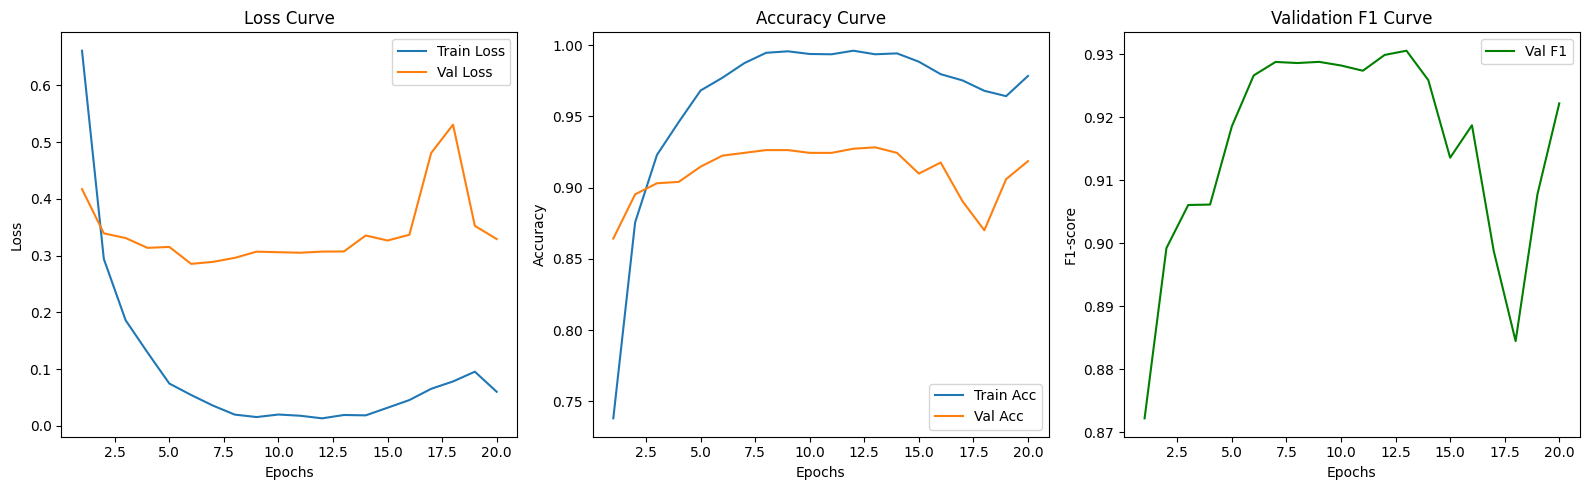

In [10]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(16,5))

# Plot Loss
plt.subplot(1,3,1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epochs"); plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

# Plot Accuracy
plt.subplot(1,3,2)
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.xlabel("Epochs"); plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

# Plot F1-score
plt.subplot(1,3,3)
plt.plot(epochs, history["val_f1"], label="Val F1", color="green")
plt.xlabel("Epochs"); plt.ylabel("F1-score")
plt.title("Validation F1 Curve")
plt.legend()

plt.tight_layout()
plt.show()

 Test Accuracy: 0.9274
 Test F1-score: 0.9323

Classification Report:
              precision    recall  f1-score   support

         dew       0.94      0.96      0.95       105
     fogsmog       0.90      0.95      0.92       128
       frost       0.84      0.90      0.87        72
       glaze       0.94      0.84      0.89        96
        hail       0.99      1.00      0.99        89
   lightning       0.98      1.00      0.99        57
        rain       0.94      0.92      0.93        79
     rainbow       1.00      1.00      1.00        35
        rime       0.90      0.97      0.93       174
   sandstorm       0.94      0.88      0.91       104
        snow       0.92      0.82      0.87        94

    accuracy                           0.93      1033
   macro avg       0.94      0.93      0.93      1033
weighted avg       0.93      0.93      0.93      1033



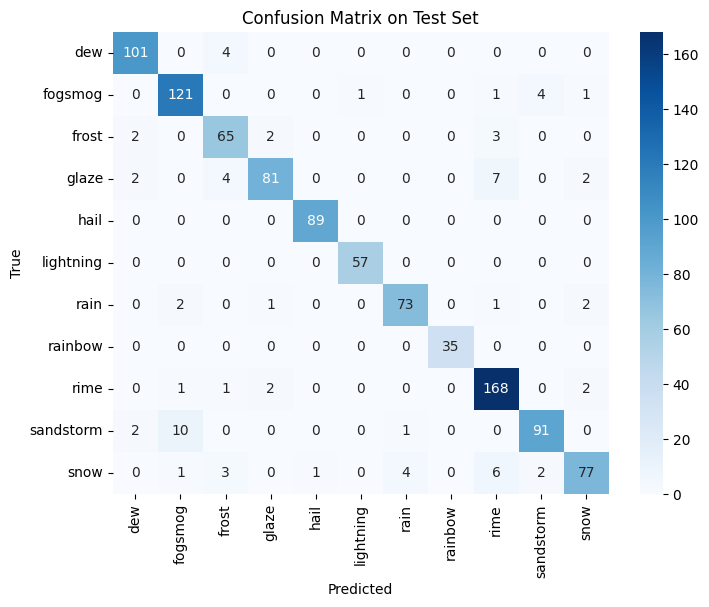

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Reload best model
best_model = ConvStemSwin(num_classes=num_classes).to(device)
best_model.load_state_dict(torch.load("best_model.pth", map_location=device))
best_model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = best_model(imgs)
        preds = outputs.argmax(dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Metrics
test_acc = accuracy_score(all_labels, all_preds)
test_f1  = f1_score(all_labels, all_preds, average="macro")

print(" Test Accuracy:", round(test_acc, 4))
print(" Test F1-score:", round(test_f1, 4))
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=train_ds.classes))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=train_ds.classes, yticklabels=train_ds.classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix on Test Set")
plt.show()

## Improved Model Definition (ConvStem + Swin-Base + Dropout)

###  Improved Model v2

In [12]:
import torch.nn as nn
import timm

class ConvStemSwinV2(nn.Module):
    def __init__(self, model_name="swin_base_patch4_window7_224", pretrained=True, num_classes=11, dropout=0.3):
        super().__init__()
        
        # Light CNN stem (keeps texture info, outputs RGB-like features)
        self.stem = nn.Sequential(
            nn.Conv2d(3, 3, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(3),
            nn.ReLU()
        )
        
        # Swin Transformer backbone
        self.backbone = timm.create_model(
            model_name, pretrained=pretrained, num_classes=0, in_chans=3
        )
        
        # Classifier head with Dropout
        self.fc = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(self.backbone.num_features, num_classes)
        )
    
    def forward(self, x):
        x = self.stem(x)
        x = self.backbone(x)   # feature extractor
        x = self.fc(x)         # classifier
        return x

# Create improved model
num_classes = len(train_ds.classes)
improved_model = ConvStemSwinV2(num_classes=num_classes, dropout=0.5).to(device)

print(" Improved Model v2 created: ConvStem + Swin-Base + Dropout")

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

 Improved Model v2 created: ConvStem + Swin-Base + Dropout


## Training Setup (Freeze Backbone)

In [13]:
# Freeze backbone parameters
for param in improved_model.backbone.parameters():
    param.requires_grad = False

# Loss function (with class weights)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Optimizer (only classifier head + stem)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, improved_model.parameters()),
    lr=1e-3, weight_decay=1e-4
)

# Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5)

print(" Stage 1 setup complete (backbone frozen, classifier training only)")

 Stage 1 setup complete (backbone frozen, classifier training only)


## Two-Stage Training (Warmup + Fine-tune)
- Stage 1: Train classifier only (frozen backbone)
- Stage 2: Fine-tune full model (unfreeze backbone)

In [14]:
def two_stage_train(model, train_loader, val_loader, class_weights, stage1_epochs=5, stage2_epochs=15):
  
    print("\n🔹 Stage 1: Training classifier head only")
    
    # Freeze backbone
    for param in model.backbone.parameters():
        param.requires_grad = False
    
    # Loss + optimizer + scheduler
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=stage1_epochs)
    
    model, history1 = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=stage1_epochs)
    
    torch.save(model.state_dict(), "stage1_model.pth")
    print(" Stage 1 complete. Model saved as stage1_model.pth")
    
    # Fine-tune full model (unfreeze backbone)
    print("\n🔹 Stage 2: Fine-tuning full model")
    
    # Unfreeze all layers
    for param in model.backbone.parameters():
        param.requires_grad = True
    
    # New optimizer with lower LR
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=stage2_epochs)
    
    model, history2 = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=stage2_epochs)
    
    torch.save(model.state_dict(), "stage2_model.pth")
    print(" Stage 2 complete. Final fine-tuned model saved as stage2_model.pth")
    
    # Merge histories
    for key in history1.keys():
        history1[key].extend(history2[key])
    
    return model, history1


#  Run Two-Stage Training
final_model, final_history = two_stage_train(improved_model, train_loader, val_loader, class_weights_tensor, stage1_epochs=5, stage2_epochs=15)


🔹 Stage 1: Training classifier head only

Epoch 1/5
------------------------------
Train Loss: 1.0659, Train Acc: 0.5884
Val Loss:   0.7011, Val Acc: 0.7633, Val F1: 0.7538
 Best model updated and saved!

Epoch 2/5
------------------------------
Train Loss: 0.6125, Train Acc: 0.7532
Val Loss:   0.5002, Val Acc: 0.8361, Val F1: 0.8382
 Best model updated and saved!

Epoch 3/5
------------------------------
Train Loss: 0.5283, Train Acc: 0.7826
Val Loss:   0.4768, Val Acc: 0.8526, Val F1: 0.8541
 Best model updated and saved!

Epoch 4/5
------------------------------
Train Loss: 0.4866, Train Acc: 0.8010
Val Loss:   0.4770, Val Acc: 0.8468, Val F1: 0.8478

Epoch 5/5
------------------------------
Train Loss: 0.4720, Train Acc: 0.8112
Val Loss:   0.4577, Val Acc: 0.8603, Val F1: 0.8606
 Best model updated and saved!

Training complete. Best Val Acc: 0.8603
 Stage 1 complete. Model saved as stage1_model.pth

🔹 Stage 2: Fine-tuning full model

Epoch 1/15
------------------------------
Trai

## Plot Final Training Curves

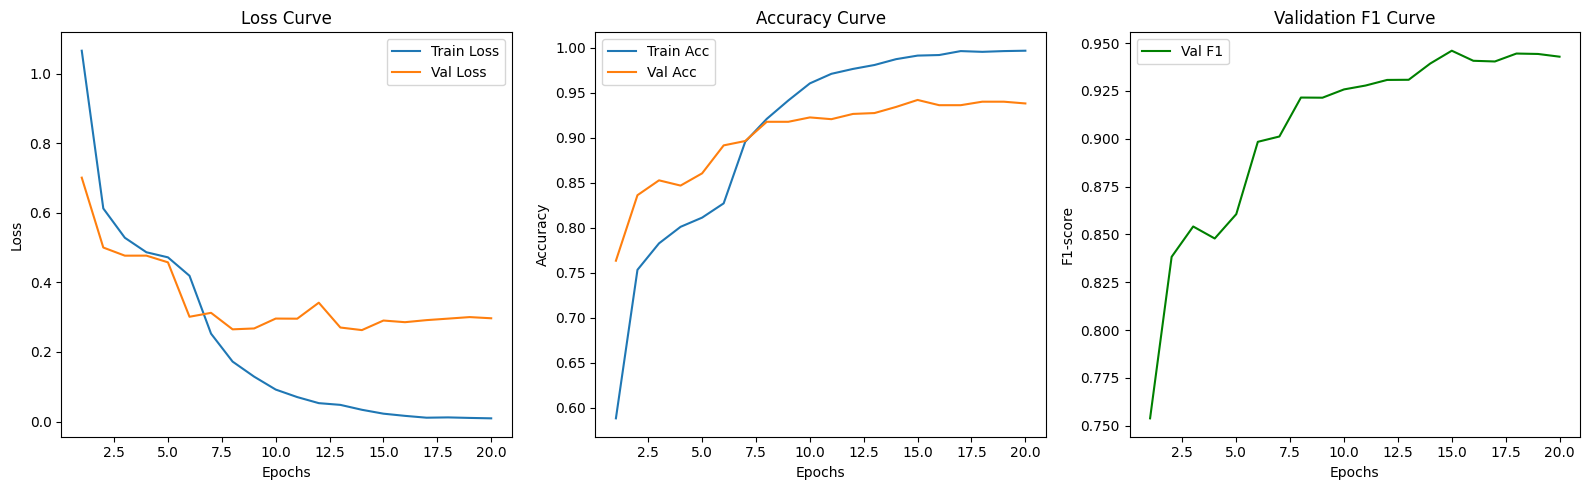

In [15]:
epochs = range(1, len(final_history["train_loss"]) + 1)

plt.figure(figsize=(16,5))

# Plot Loss
plt.subplot(1,3,1)
plt.plot(epochs, final_history["train_loss"], label="Train Loss")
plt.plot(epochs, final_history["val_loss"], label="Val Loss")
plt.xlabel("Epochs"); plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

# Plot Accuracy
plt.subplot(1,3,2)
plt.plot(epochs, final_history["train_acc"], label="Train Acc")
plt.plot(epochs, final_history["val_acc"], label="Val Acc")
plt.xlabel("Epochs"); plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

# Plot F1-score
plt.subplot(1,3,3)
plt.plot(epochs, final_history["val_f1"], label="Val F1", color="green")
plt.xlabel("Epochs"); plt.ylabel("F1-score")
plt.title("Validation F1 Curve")
plt.legend()

plt.tight_layout()
plt.show()

## Evaluate Final Model on Test Set

 Final Test Accuracy: 0.9371
 Final Test F1-score: 0.9403

Classification Report:
              precision    recall  f1-score   support

         dew       0.96      0.99      0.98       105
     fogsmog       0.89      0.98      0.94       128
       frost       0.87      0.85      0.86        72
       glaze       0.89      0.89      0.89        96
        hail       0.96      0.99      0.97        89
   lightning       1.00      1.00      1.00        57
        rain       0.96      0.91      0.94        79
     rainbow       1.00      0.97      0.99        35
        rime       0.94      0.93      0.93       174
   sandstorm       0.99      0.89      0.94       104
        snow       0.91      0.91      0.91        94

    accuracy                           0.94      1033
   macro avg       0.94      0.94      0.94      1033
weighted avg       0.94      0.94      0.94      1033



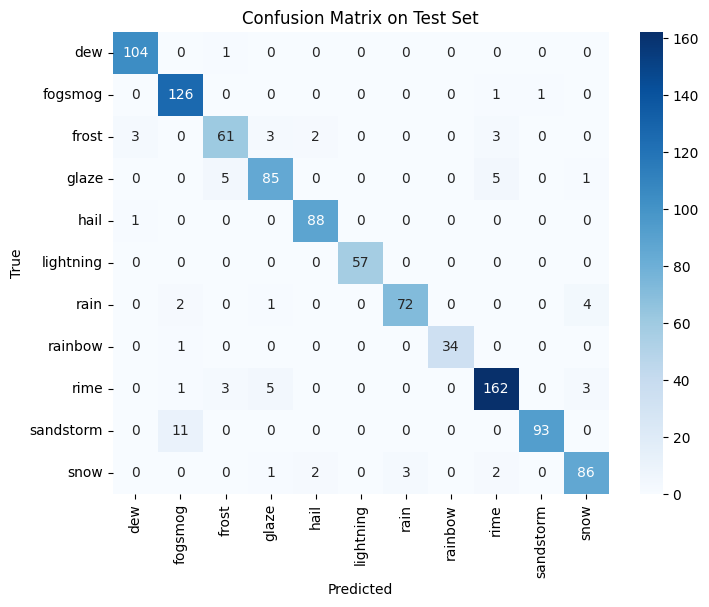

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Reload final stage 2 model
best_final_model = ConvStemSwinV2(num_classes=num_classes, dropout=0.5).to(device)
best_final_model.load_state_dict(torch.load("stage2_model.pth", map_location=device))
best_final_model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = best_final_model(imgs)
        preds = outputs.argmax(dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Metrics
test_acc = accuracy_score(all_labels, all_preds)
test_f1  = f1_score(all_labels, all_preds, average="macro")

print(" Final Test Accuracy:", round(test_acc, 4))
print(" Final Test F1-score:", round(test_f1, 4))
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=train_ds.classes))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=train_ds.classes, yticklabels=train_ds.classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix on Test Set")
plt.show()

## Robust Fine-Tuning (Continue from 0.94 Model)

In [17]:
from torchvision import transforms

# Realistic Weather Augmentations 
train_transforms_robust = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.25, hue=0.05),
    transforms.RandomApply([transforms.GaussianBlur(3)], p=0.2),
    transforms.RandomApply([transforms.RandomPerspective(distortion_scale=0.3, p=0.3)], p=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Reload datasets with new augmentations
train_ds_robust = datasets.ImageFolder(train_dir, transform=train_transforms_robust)
val_ds_robust = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_ds_robust = datasets.ImageFolder(test_dir, transform=val_test_transforms)

train_loader_robust = DataLoader(train_ds_robust, batch_size=32, shuffle=True, num_workers=2)
val_loader_robust = DataLoader(val_ds_robust, batch_size=32, shuffle=False, num_workers=2)

# Load previous model 
robust_model = ConvStemSwinV2(num_classes=num_classes, dropout=0.5).to(device)
robust_model.load_state_dict(torch.load("stage2_model.pth", map_location=device))

# Fine-tuning setup 
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.AdamW(robust_model.parameters(), lr=1e-5, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# Fine-tune for 5–10 epochs 
robust_model, robust_history = train_model(
    robust_model, train_loader_robust, val_loader_robust,
    criterion, optimizer, scheduler, num_epochs=8
)

torch.save(robust_model.state_dict(), "robust_model_v3.pth")
print(" Robust fine-tuning complete. Model saved as robust_model_v3.pth")


Epoch 1/8
------------------------------
Train Loss: 0.0619, Train Acc: 0.9758
Val Loss:   0.2887, Val Acc: 0.9408, Val F1: 0.9443
 Best model updated and saved!

Epoch 2/8
------------------------------
Train Loss: 0.0393, Train Acc: 0.9837
Val Loss:   0.3080, Val Acc: 0.9379, Val F1: 0.9424

Epoch 3/8
------------------------------
Train Loss: 0.0340, Train Acc: 0.9850
Val Loss:   0.3230, Val Acc: 0.9447, Val F1: 0.9480
 Best model updated and saved!

Epoch 4/8
------------------------------
Train Loss: 0.0327, Train Acc: 0.9858
Val Loss:   0.3316, Val Acc: 0.9379, Val F1: 0.9427

Epoch 5/8
------------------------------
Train Loss: 0.0280, Train Acc: 0.9873
Val Loss:   0.3254, Val Acc: 0.9379, Val F1: 0.9416

Epoch 6/8
------------------------------
Train Loss: 0.0270, Train Acc: 0.9879
Val Loss:   0.3109, Val Acc: 0.9428, Val F1: 0.9469

Epoch 7/8
------------------------------
Train Loss: 0.0205, Train Acc: 0.9925
Val Loss:   0.3214, Val Acc: 0.9447, Val F1: 0.9484

Epoch 8/8
---